In [ ]:
## Installing relevant libraries
!pip install xgboost lightgbm sentence-transformers tensorflow shap
!pip install transformers datasets

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap


In [ ]:
# ============================================================
# Dataset loader — auto-detects environment, no setup needed
# Cache path is printed below so you always know where data lives
# ============================================================

import os, pathlib
import pandas as pd
from sklearn.model_selection import train_test_split

# ── Determine the best persistent cache directory for this environment ──────
def _get_cache_path() -> pathlib.Path:
    """Return the best location to cache quora_train.csv for this environment."""
    # Kaggle: /kaggle/working is persistent across saved versions
    if pathlib.Path("/kaggle/working").exists():
        return pathlib.Path("/kaggle/working/quora_train.csv")
    # Colab: prefer Google Drive if already mounted, else use ~/.cache
    colab_drive = pathlib.Path("/content/drive/MyDrive")
    if colab_drive.exists():
        cache_dir = colab_drive / "qqp_cache"
        cache_dir.mkdir(parents=True, exist_ok=True)
        return cache_dir / "quora_train.csv"
    if pathlib.Path("/content").exists():   # Colab without Drive
        cache_dir = pathlib.Path("/root/.cache/qqp")
        cache_dir.mkdir(parents=True, exist_ok=True)
        return cache_dir / "quora_train.csv"
    # Local: same directory as this notebook
    nb_dir = pathlib.Path(globals().get("__vsc_ipynb_file__",
                          os.environ.get("JUPYTER_RUNTIME_DIR", "."))).parent
    if not nb_dir.exists():
        nb_dir = pathlib.Path(".")
    return nb_dir / "quora_train.csv"

CACHE_PATH = _get_cache_path()
print(f"[Dataset] Cache path : {CACHE_PATH}")

def load_quora() -> pd.DataFrame:
    """
    Auto-detects environment and loads the QQP dataset.
    Tries 4 paths in order — no manual steps needed.
    """

    # ── PATH 1: Kaggle kernel input ───────────────────────────────────────
    for kp in [
        "/kaggle/input/competitions/quora-question-pairs/train.csv.zip",
        "/kaggle/input/quora-question-pairs/train.csv",
    ]:
        p = pathlib.Path(kp)
        if p.exists():
            print(f"[Dataset] Source : Kaggle ({kp})")
            return pd.read_csv(p)

    # ── PATH 2: cached / local CSV on disk ────────────────────────────────
    for local in [CACHE_PATH, pathlib.Path("quora_train.csv"), pathlib.Path("train.csv")]:
        p = pathlib.Path(local)
        if p.exists():
            print(f"[Dataset] Source : cached file ({p})")
            return pd.read_csv(p)

    # ── PATH 3: HuggingFace GLUE/QQP (primary download) ─────────────────
    # Officially maintained by nyu-mll — no trust_remote_code required.
    # Schema: question1, question2, label  (we rename label → is_duplicate)
    print("[Dataset] Downloading from HuggingFace (GLUE/QQP) ...")
    print("          ~60 MB, saved to cache after download.")
    try:
        from datasets import load_dataset, concatenate_datasets
        ds_train = load_dataset("nyu-mll/glue", "qqp", split="train")
        ds_val   = load_dataset("nyu-mll/glue", "qqp", split="validation")
        combined = concatenate_datasets([ds_train, ds_val])
        df = combined.to_pandas()
        df = df.rename(columns={"label": "is_duplicate"})
        df = df[["question1", "question2", "is_duplicate"]].copy()
        df = df.reset_index().rename(columns={"index": "id"})
        df["qid1"] = df["id"] * 2
        df["qid2"] = df["id"] * 2 + 1
        df.to_csv(CACHE_PATH, index=False)
        print(f"[Dataset] Saved to {CACHE_PATH}")
        print( "[Dataset] Future runs will load from cache (Path 2) — no re-download.")
        return df
    except Exception as e1:
        print(f"[Dataset] GLUE/QQP failed ({e1}). Trying legacy 'quora' dataset ...")

    # ── PATH 4: legacy 'quora' HF dataset (last resort) ──────────────────
    try:
        from datasets import load_dataset
        ds = load_dataset("quora", split="train", trust_remote_code=True)
        df = ds.to_pandas()
        df["question1"]    = df["questions"].apply(lambda x: x["text"][0])
        df["question2"]    = df["questions"].apply(lambda x: x["text"][1])
        df["is_duplicate"] = df["is_duplicate"].astype(int)
        df = df.reset_index().rename(columns={"index": "id"})
        df["qid1"] = df["id"] * 2
        df["qid2"] = df["id"] * 2 + 1
        df = df[["id", "qid1", "qid2", "question1", "question2", "is_duplicate"]].copy()
        df.to_csv(CACHE_PATH, index=False)
        print(f"[Dataset] Saved to {CACHE_PATH}")
        return df
    except Exception as e2:
        raise RuntimeError(
            f"All automatic download paths failed.\n"
            f"  Path 3 error: {e1}\n"
            f"  Path 4 error: {e2}\n\n"
            "One-time manual fix:\n"
            "  1. Go to https://www.kaggle.com/c/quora-question-pairs/data\n"
            "  2. Download train.csv.zip  →  extract  →  rename to quora_train.csv\n"
            f"  3. Place it at: {CACHE_PATH}\n"
            "  4. Re-run this cell — it will be detected automatically (Path 2)."
        ) from e2

_full_df = load_quora()
_full_df = _full_df.dropna(subset=["question1", "question2"]).reset_index(drop=True)
_full_df["question1"] = _full_df["question1"].fillna("").astype(str)
_full_df["question2"] = _full_df["question2"].fillna("").astype(str)

train_df, test_df = train_test_split(
    _full_df, test_size=0.2, random_state=42,
    stratify=_full_df["is_duplicate"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Full dataset : {len(_full_df):,} rows")
print(f"Train split  : {len(train_df):,} rows")
print(f"Test split   : {len(test_df):,} rows")
print(f"Duplicate %  : {_full_df['is_duplicate'].mean():.1%}")
print("\nReady. Proceed to the next cell.")


Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test.csv', 'train.csv', 'sample_submission.csv', 'submission_logistic_regression.csv', 'submission_xgboost.csv', 'submission_lightgbm.csv', 'submission_gru.csv', 'NLP_QQP_Lucius_code.ipynb', 'NLP_QQP_Code_v2_DS=35000.ipynb']
Files inside Data folder:
['test.csv', 'train.csv', 'sample_submission.csv', 'submission_logistic_regression.csv', 'submission_xgboost.csv', 'submission_lightgbm.csv', 'submission_gru.csv', 'NLP_QQP_Lucius_code.ipynb', 'NLP_QQP_Code_v2_DS=35000.ipynb']

Train shape: (404290, 6)
Test shape: (2345796, 3)


In [ ]:
df = train_df
print("The dataframe shape is: ", df.shape)
df.head()
df_test = test_df
print("The dataframe shape is: ", test_df.shape)


The dataframe shape is:  (404290, 6)
The dataframe shape is:  (2345796, 3)


In [ ]:
new_df = df.sample(35000, random_state=2)

In [ ]:
## Describing info of new_df
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 398782 to 341577
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            35000 non-null  int64 
 1   qid1          35000 non-null  int64 
 2   qid2          35000 non-null  int64 
 3   question1     35000 non-null  object
 4   question2     35000 non-null  object
 5   is_duplicate  35000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.9+ MB


In [ ]:
## Looking up isnull
new_df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [ ]:
new_df.duplicated().sum()

np.int64(0)

is_duplicate
0    22172
1    12828
Name: count, dtype: int64
is_duplicate
0    63.348571
1    36.651429
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

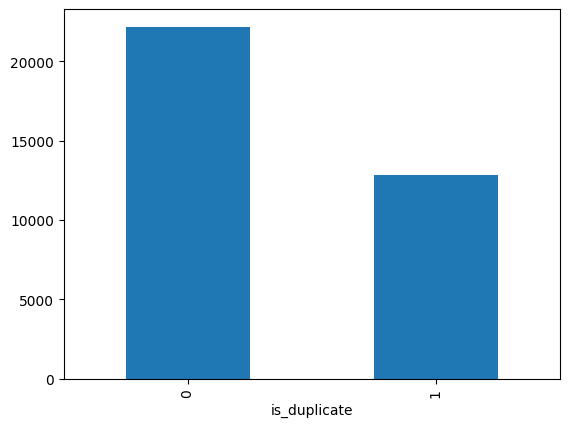

In [ ]:
print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [ ]:
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 63957
Number of questions getting repeated 4317


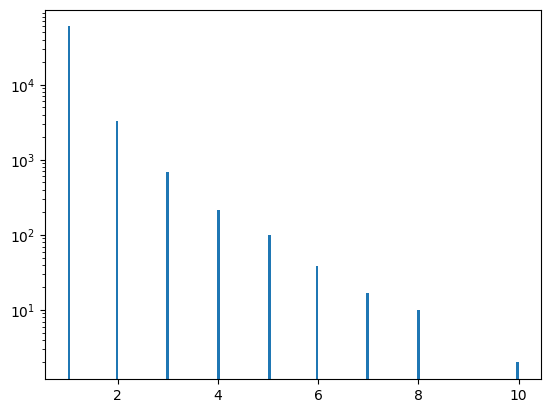

In [ ]:
# Repeated questions histogram
import matplotlib.pyplot as plt
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [ ]:
# Feature Engineering
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [ ]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(str(row).split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(str(row).split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [ ]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), str(row['question1']).split()))
    w2 = set(map(lambda word: word.lower().strip(), str(row['question2']).split()))
    return len(w1 & w2)

In [ ]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [ ]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), str(row['question1']).split()))
    w2 = set(map(lambda word: word.lower().strip(), str(row['question2']).split()))
    return (len(w1) + len(w2))

In [ ]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [ ]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


minimum characters 2
maximum characters 391
average num of characters 59


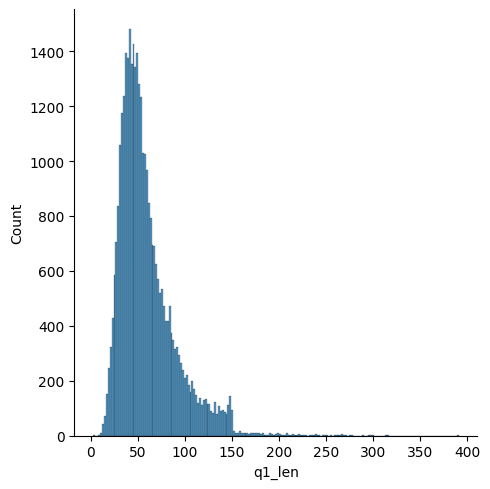

In [ ]:
# Analysis of features
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average num of characters',int(new_df['q1_len'].mean()))

minimum characters 6
maximum characters 1151
average num of characters 60


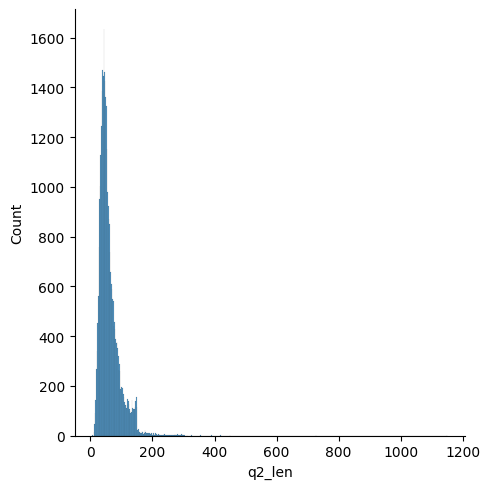

In [ ]:
sns.displot(new_df['q2_len'])
print('minimum characters', new_df['q2_len'].min())
print('maximum characters', new_df['q2_len'].max())
print('average num of characters',int(new_df['q2_len'].mean()))

minimum words 1
maximum words 72
average num of words 10


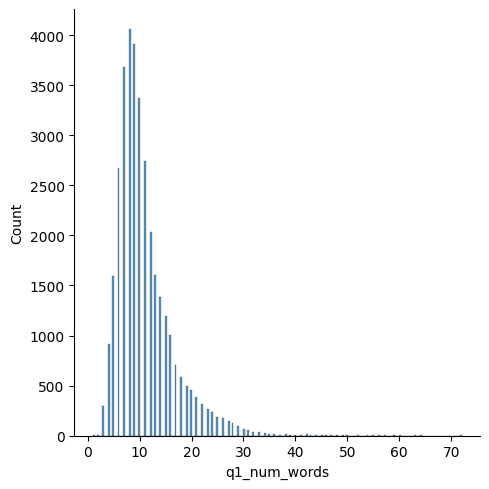

In [ ]:
sns.displot(new_df['q1_num_words'])
print('minimum words',new_df['q1_num_words'].min())
print('maximum words',new_df['q1_num_words'].max())
print('average num of words',int(new_df['q1_num_words'].mean()))

minimum words 1
maximum words 237
average num of words 11


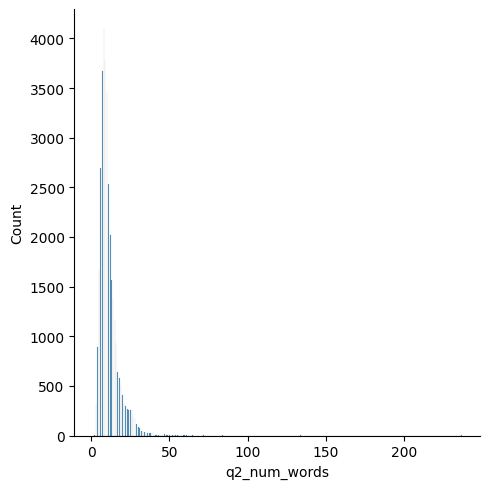

In [ ]:
sns.displot(new_df['q2_num_words'])
print('minimum words',new_df['q2_num_words'].min())
print('maximum words',new_df['q2_num_words'].max())
print('average num of words',int(new_df['q2_num_words'].mean()))

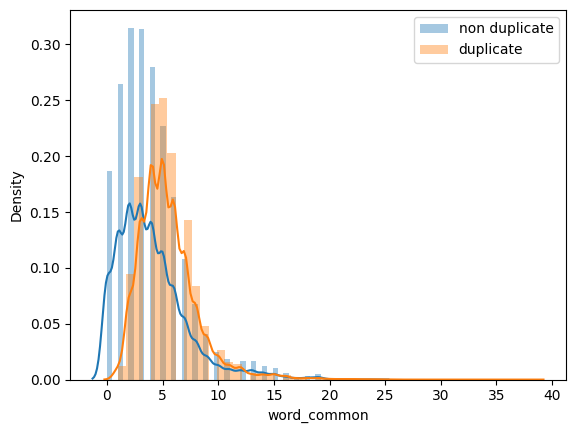

In [ ]:
# common words
sns.histplot(kde=True, new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.histplot(kde=True, new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

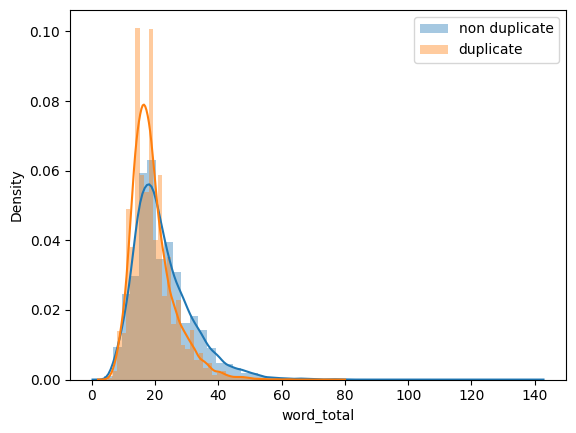

In [ ]:
# total words
sns.histplot(kde=True, new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.histplot(kde=True, new_df[new_df['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

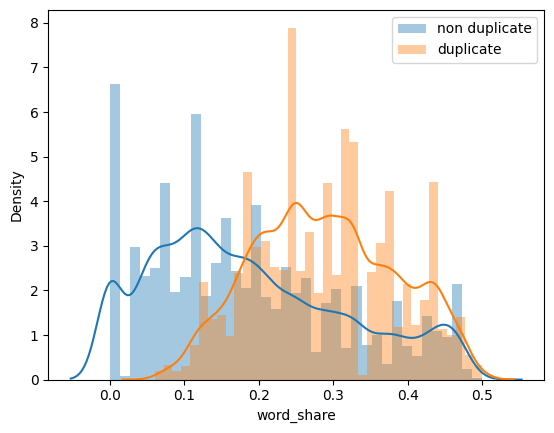

In [ ]:
# word share
sns.histplot(kde=True, new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.histplot(kde=True, new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [ ]:

ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
398782,What is the best marketing automation tool for...,What is the best marketing automation tool for...
115086,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...
327711,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...
367788,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...
151235,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...


In [ ]:
print(new_df.head())

            id    qid1    qid2  \
398782  398782  496695  532029   
115086  115086  187729  187730   
327711  327711  454161  454162   
367788  367788  498109  491396   
151235  151235  237843   50930   

                                                question1  \
398782  What is the best marketing automation tool for...   
115086  I am poor but I want to invest. What should I do?   
327711  I am from India and live abroad. I met a guy f...   
367788  Why do so many people in the U.S. hate the sou...   
151235                Consequences of Bhopal gas tragedy?   

                                                question2  is_duplicate  \
398782  What is the best marketing automation tool for...             1   
115086  I am quite poor and I want to be very rich. Wh...             0   
327711  T.I.E.T to Thapar University to Thapar Univers...             0   
367788  My boyfriend doesnt feel guilty when he hurts ...             0   
151235  What was the reason behind the Bhopal gas tra

In [ ]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(35000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Fill NaN values with empty string
ques_df['question1'] = ques_df['question1'].fillna('')
ques_df['question2'] = ques_df['question2'].fillna('')

# Merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1q2_vectors = cv.fit_transform(questions).toarray()

# Split back into q1 and q2 arrays
q1_arr, q2_arr = np.vsplit(q1q2_vectors, 2)

In [ ]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(35000, 6000)

In [ ]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(35000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7715714285714286

In [ ]:
## Printing Evaluation Metrics
def evaluate_model(name, y_true, pred_probs):
  # Defining predictions here
  preds=(pred_probs>0.5).astype(int)
  acc=accuracy_score(y_true,preds)
  loss=log_loss(y_true,pred_probs)
  f1=f1_score(y_true, preds)
  ## Printing metrics
  print("\n", name)
  print("Accuracy: ",acc)
  print("Loss: ", loss)
  print("F1 Score: ", f1)

In [ ]:
features = final_df.columns.drop("is_duplicate")
print(len(features), X_train.shape[1])

6007 6007


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

import shap


 Logistic Regression results: 
Accuracy:  0.76
Loss:  0.4867595307602378
F1 Score:  0.6608800968914009


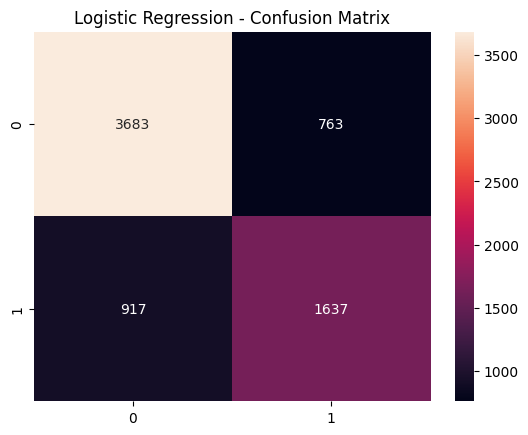

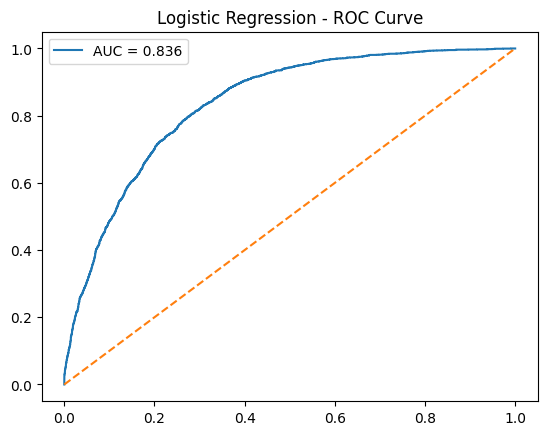

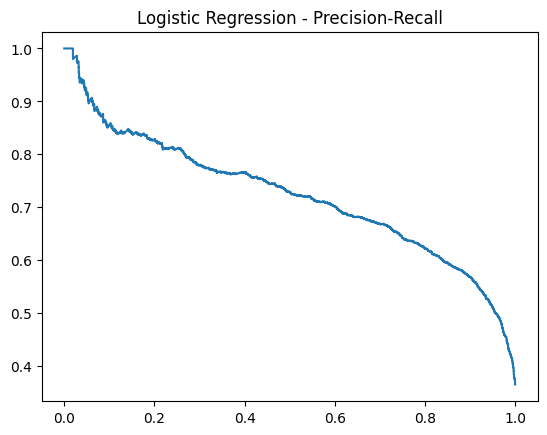

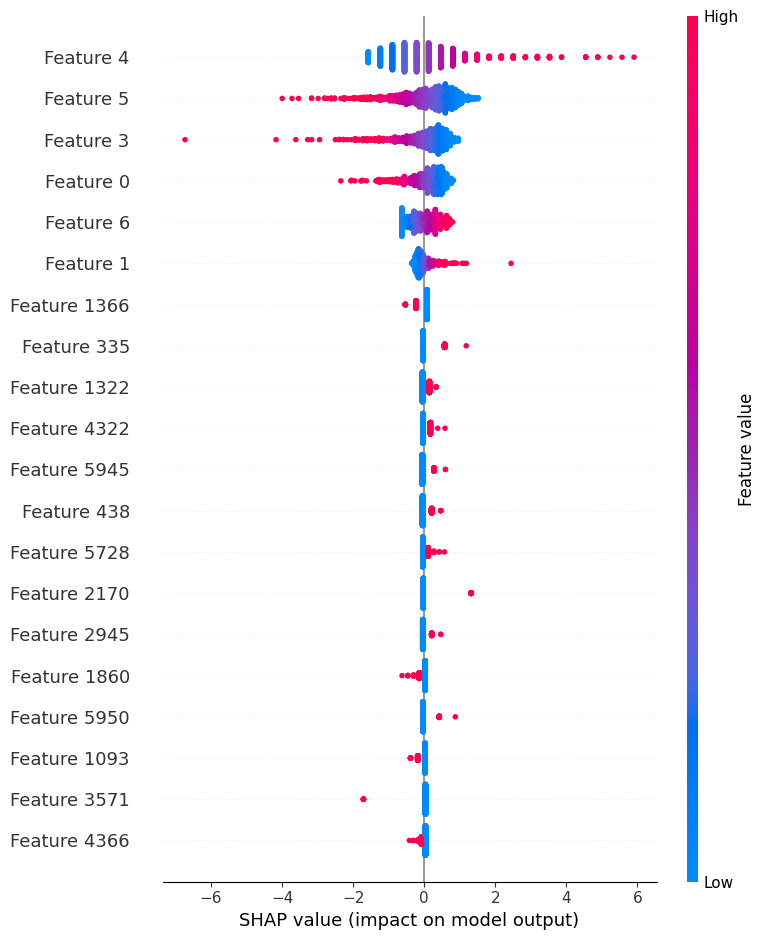

In [ ]:
## Implementing Logistic Regression Model
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred=lr.predict_proba(X_test)[:,1]
evaluate_model("Logistic Regression results: ", y_test, lr_pred)

# Predictions
y_pred_prob = lr.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.title("Logistic Regression - Precision-Recall")
plt.show()

# SHAP
explainer = shap.Explainer(lr, X_train)
shap_values = explainer(X_test[:1000])
shap.summary_plot(shap_values, X_test[:1000])



 XGB Classifier results: 
Accuracy:  0.7775714285714286
Loss:  0.43184944406764775
F1 Score:  0.6905187835420393


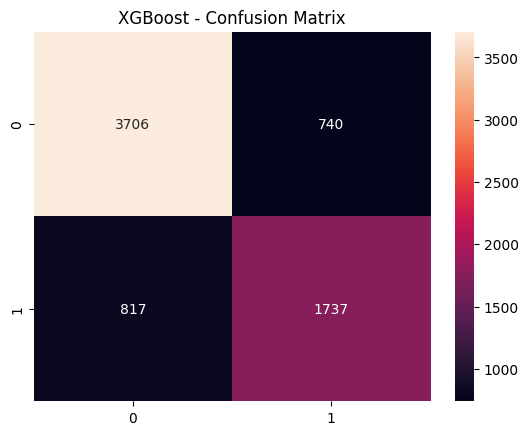

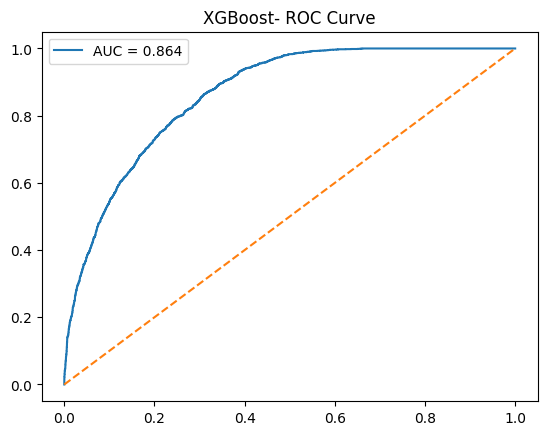

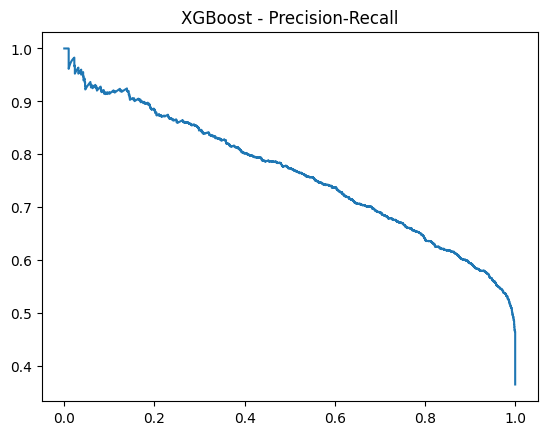

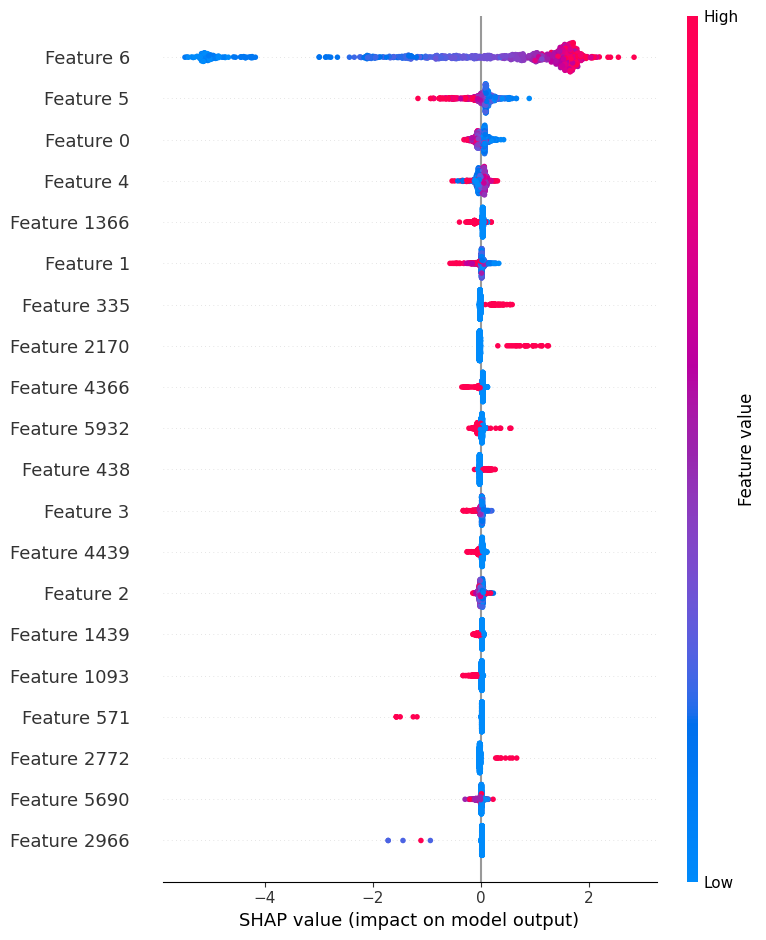

In [ ]:
## Implementing XGBoost
xgb_model=XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.1)
xgb_model.fit(X_train, y_train)
xgb_pred=xgb_model.predict_proba(X_test)[:,1]
evaluate_model("XGB Classifier results: ", y_test, xgb_pred)

# Predictions
y_pred_prob = xgb_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost - Confusion Matrix")
plt.show()

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_prob)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {roc_auc_xgb:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("XGBoost- ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.title("XGBoost - Precision-Recall")
plt.show()

# SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test[:1000])
shap.summary_plot(shap_values, X_test[:1000])


[LightGBM] [Info] Number of positive: 10274, number of negative: 17726
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.161767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8932
[LightGBM] [Info] Number of data points in the train set: 28000, number of used features: 3061
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.366929 -> initscore=-0.545416
[LightGBM] [Info] Start training from score -0.545416

 Ligt GBM results: 
Accuracy:  0.7844285714285715
Loss:  0.4172987554587277
F1 Score:  0.7025428740390302


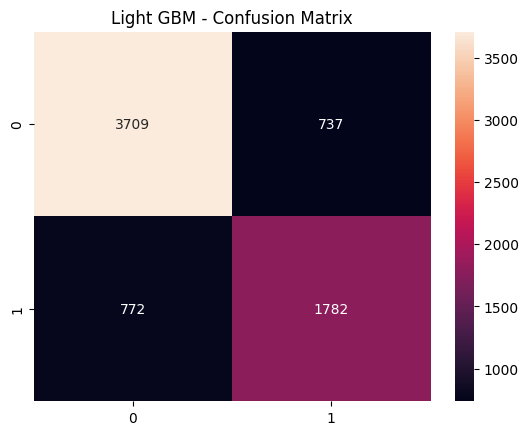

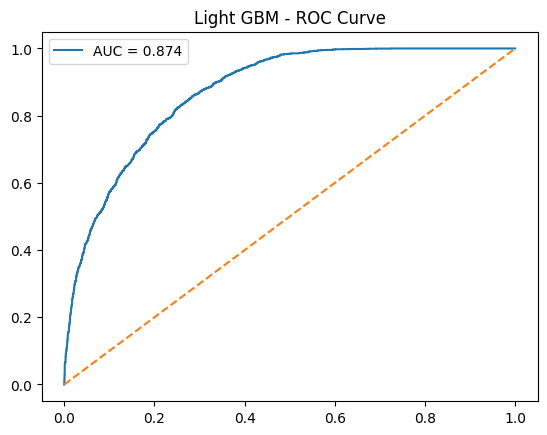

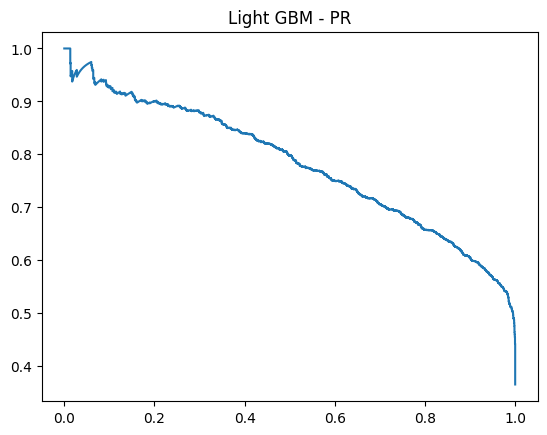

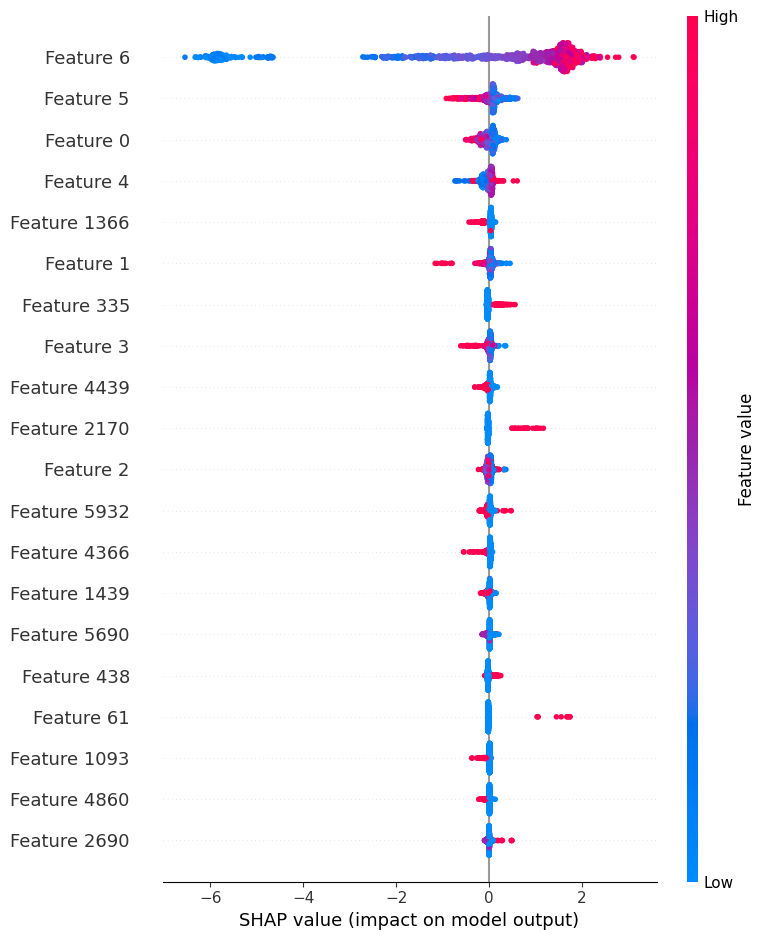

In [ ]:
# Light GBM Classifier
lgb_model=lgb.LGBMClassifier(n_estimators=400,learning_rate=0.05)
lgb_model.fit(X_train, y_train)
lgb_pred=lgb_model.predict_proba(X_test)[:,1]
evaluate_model("Ligt GBM results: ", y_test, lgb_pred)

y_pred_prob = lgb_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Light GBM - Confusion Matrix")
plt.show()


fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_prob)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

plt.plot(fpr_lgb, tpr_lgb, label=f"AUC = {roc_auc_lgb:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("Light GBM - ROC Curve")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.title("Light GBM - PR")
plt.show()

# SHAP
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test[:1000])
shap.summary_plot(shap_values, X_test[:1000])


In [ ]:
!pip install -q sentence-transformers torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn

In [ ]:
def plot_all_metrics(name, y_true, y_pred_prob):
    y_pred = (y_pred_prob > 0.5).astype(int)
    acc=accuracy_score(y_true, y_pred)
    print("The accurcy is: ", acc)

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
    plt.plot(recall, precision)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.show()

    loss = log_loss(y_true, y_pred_prob)
    f1 = f1_score(y_true, y_pred)
    print(f"{name} Log Loss: {loss:4f}")
    print(f"{name} F1 Score: {f1:4f}")

In [ ]:
new_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common',
       'word_total', 'word_share'],
      dtype='object')

In [ ]:
final_df.columns

Index(['is_duplicate',       'q1_len',       'q2_len', 'q1_num_words',
       'q2_num_words',  'word_common',   'word_total',   'word_share',
                    0,              1,
       ...
                 2990,           2991,           2992,           2993,
                 2994,           2995,           2996,           2997,
                 2998,           2999],
      dtype='object', length=6008)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
def run_embedding_model(model_name, model_label):

    print(f"\nRunning {model_label}")

    model = SentenceTransformer(model_name)
    # TRAIN EMBEDDINGS

    emb1 = model.encode(new_df.question1.tolist(), batch_size=256, show_progress_bar=True)
    emb2 = model.encode(new_df.question2.tolist(), batch_size=256, show_progress_bar=True)

    similarities = cosine_similarity(emb1, emb2).diagonal()

    new_df[f"{model_label}_sim"] = similarities

    X = new_df[[f"{model_label}_sim"]]
    y = new_df["is_duplicate"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler      = StandardScaler()
    X_train_s   = scaler.fit_transform(X_train)
    X_val_s     = scaler.transform(X_val)

    clf = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
    clf.fit(X_train_s, y_train)

    preds = clf.predict_proba(X_val_s)[:,1]

    plot_all_metrics(model_label, y_val, preds)

    return clf, model


Running BGE


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

The accurcy is:  0.7875714285714286


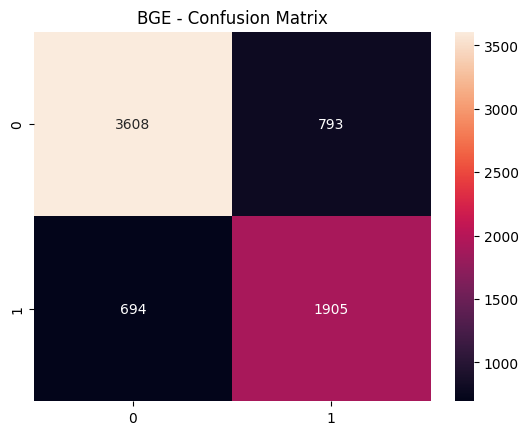

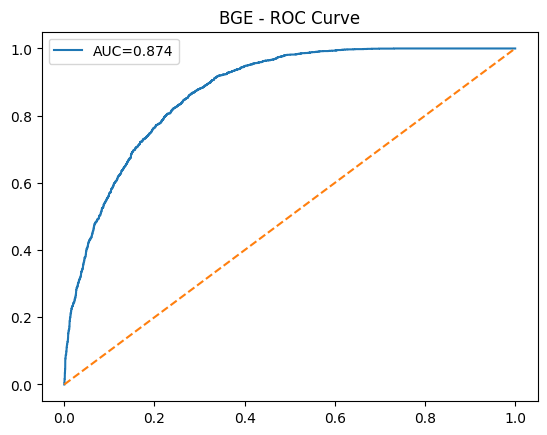

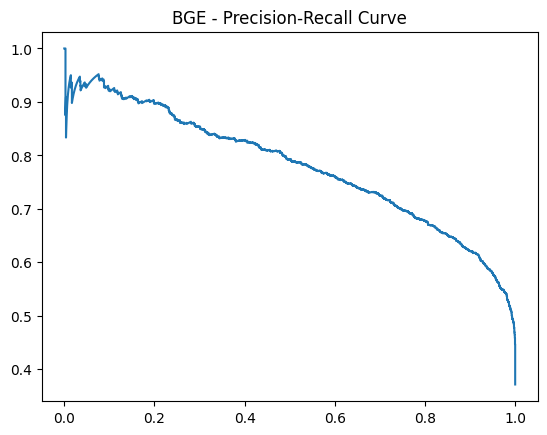

BGE Log Loss: 0.419660
BGE F1 Score: 0.719275

Running E5


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

The accurcy is:  0.7555714285714286


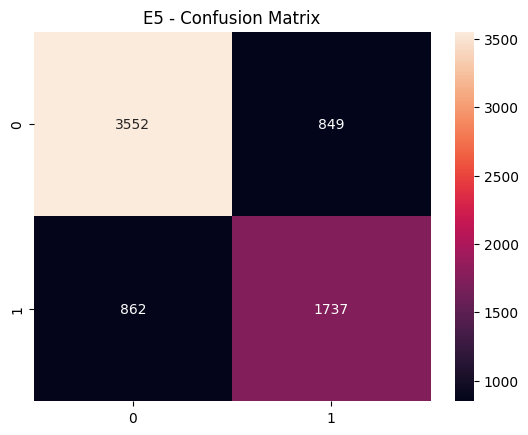

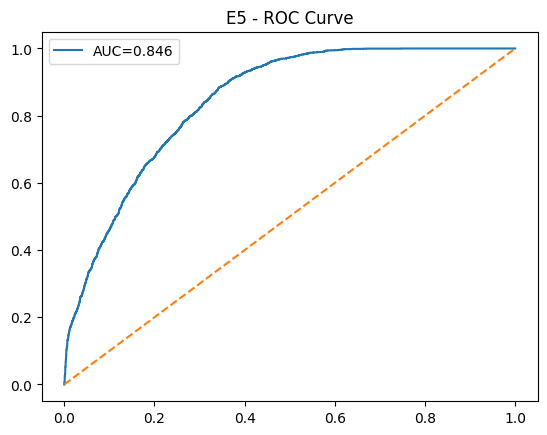

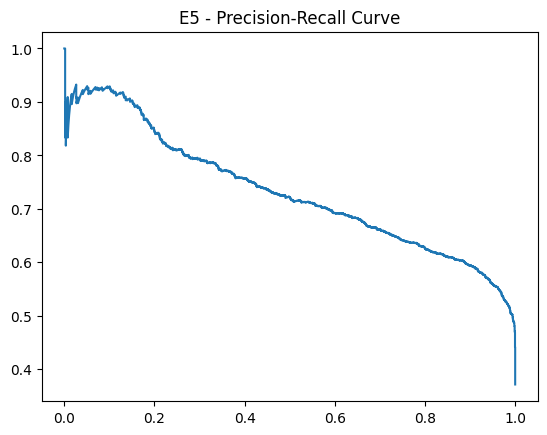

E5 Log Loss: 0.457272
E5 F1 Score: 0.670010

Running GTE


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

The accurcy is:  0.7691428571428571


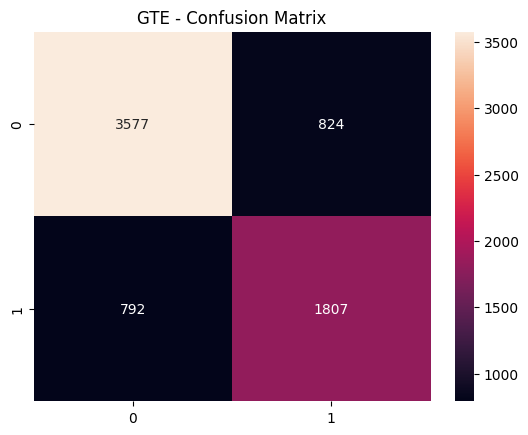

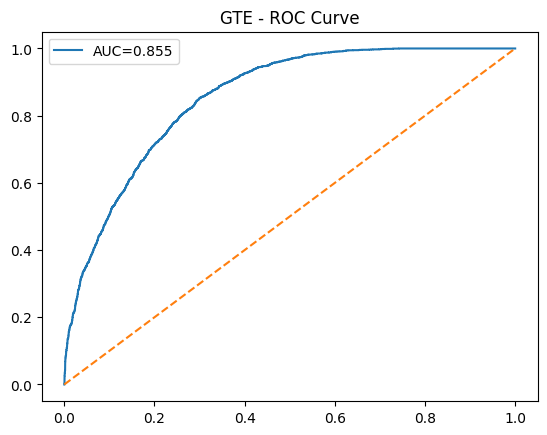

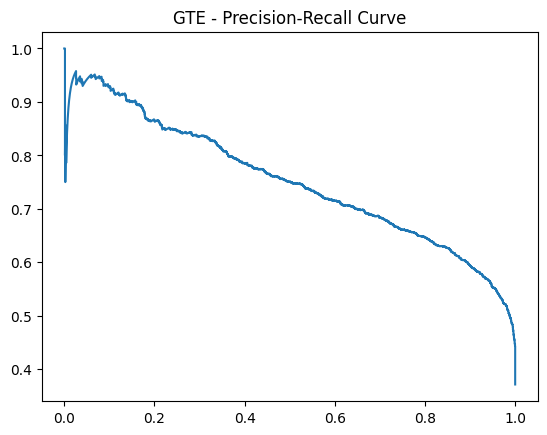

GTE Log Loss: 0.446674
GTE F1 Score: 0.691013

Running SBERT


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

The accurcy is:  0.7838571428571428


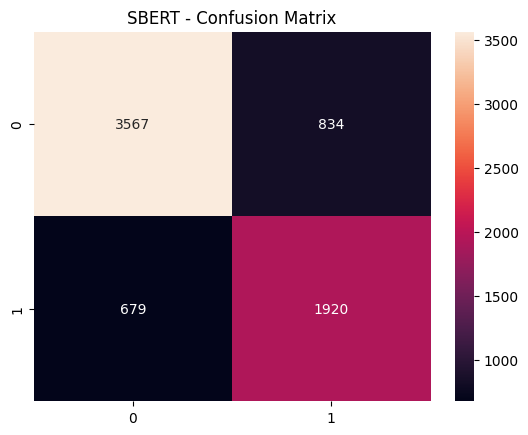

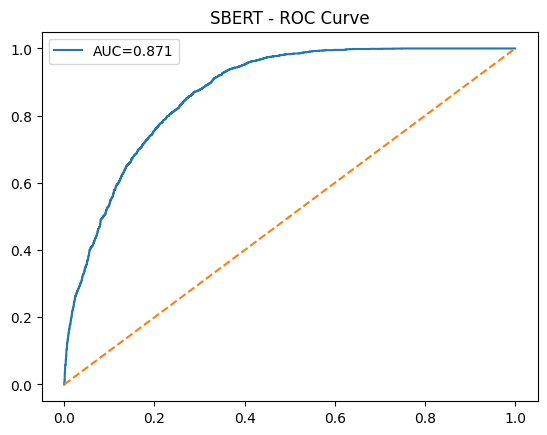

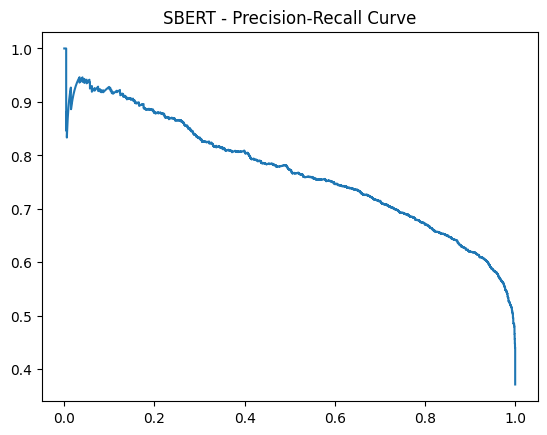

SBERT Log Loss: 0.422136
SBERT F1 Score: 0.717355


(LogisticRegression(max_iter=1000, n_jobs=-1),
 SentenceTransformer(
   (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
   (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
   (2): Normalize()
 ))

In [ ]:
# BGE
run_embedding_model("BAAI/bge-small-en-v1.5", "BGE")

# E5
run_embedding_model("intfloat/e5-base-v2", "E5")

# GTE
run_embedding_model("thenlper/gte-base", "GTE")

# SBERT
run_embedding_model("sentence-transformers/all-MiniLM-L6-v2", "SBERT")


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 50

tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(new_df.question1.tolist() + new_df.question2.tolist())

q1_seq = tokenizer.texts_to_sequences(new_df.question1.tolist())
q2_seq = tokenizer.texts_to_sequences(new_df.question2.tolist())

q1_pad = pad_sequences(q1_seq, maxlen=MAX_LEN)
q2_pad = pad_sequences(q2_seq, maxlen=MAX_LEN)

y = final_df["is_duplicate"].values

X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    q1_pad, q2_pad, y, test_size=0.2, random_state=42
)

In [ ]:
class SiameseGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim*2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.embedding(x)
        _, h = self.gru(x)
        return h.squeeze(0)

    def forward(self, q1, q2):
        h1 = self.encode(q1)
        h2 = self.encode(q2)
        x = torch.cat([h1, h2], dim=1)
        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseGRU(vocab_size=20000).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

X1_train_t = torch.tensor(X1_train).to(device)
X2_train_t = torch.tensor(X2_train).to(device)
y_train_t = torch.tensor(y_train).float().to(device)

for epoch in range(3):
    model.train()

    preds = model(X1_train_t, X2_train_t).squeeze()
    loss = criterion(preds, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6793
Epoch 2, Loss: 0.6727
Epoch 3, Loss: 0.6667


The accurcy is:  0.6288571428571429


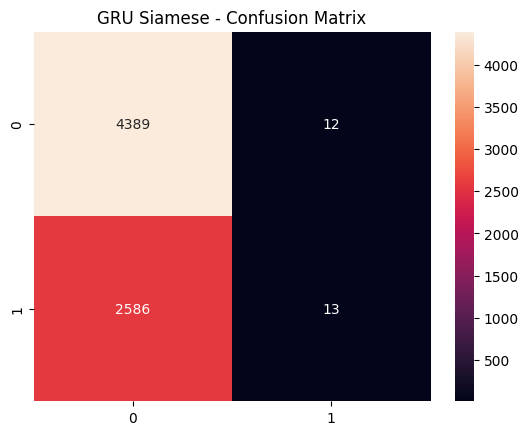

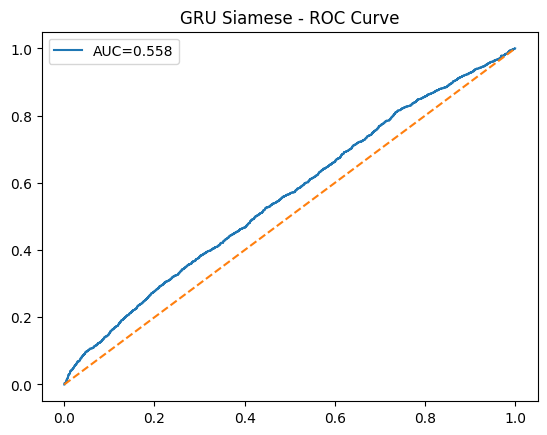

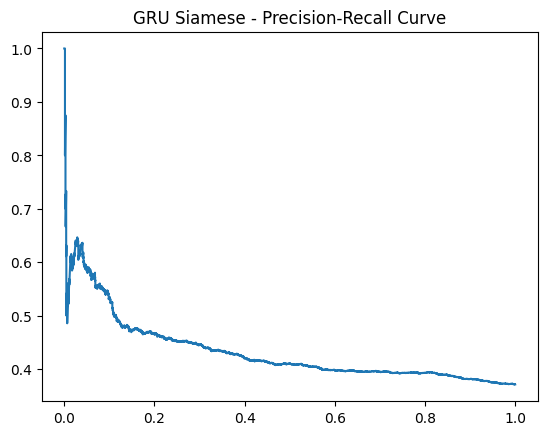

GRU Siamese Log Loss: 0.663122
GRU Siamese F1 Score: 0.009909


In [ ]:
model.eval()

X1_val_t = torch.tensor(X1_val).to(device)
X2_val_t = torch.tensor(X2_val).to(device)

with torch.no_grad():
    preds = model(X1_val_t, X2_val_t).squeeze().cpu().numpy()

plot_all_metrics("GRU Siamese", y_val, preds)

In [ ]:
def build_embedding_features(emb1, emb2):

    cos_sim = cosine_similarity(emb1, emb2).diagonal()

    dot = np.sum(emb1 * emb2, axis=1)

    l2_dist = np.linalg.norm(emb1 - emb2, axis=1)

    manhattan = np.sum(np.abs(emb1 - emb2), axis=1)

    return pd.DataFrame({
        "cos_sim": cos_sim,
        "dot_product": dot,
        "l2_dist": l2_dist,
        "manhattan": manhattan
    })

In [ ]:
def run_embedding_model_updated(model_name, model_label):

    print(f"\nRunning {model_label}")

    model = SentenceTransformer(model_name)


    # EMBEDDINGS


    emb1 = model.encode(new_df.question1.tolist(),
                        batch_size=256,
                        normalize_embeddings=True)

    emb2 = model.encode(new_df.question2.tolist(),
                        batch_size=256,
                        normalize_embeddings=True)


    # FEATURES (UPGRADED)


    feat_df = build_embedding_features(emb1, emb2)

    # Optional: prefix columns
    feat_df.columns = [f"{model_label}_{c}" for c in feat_df.columns]

    X = feat_df
    y = new_df["is_duplicate"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler      = StandardScaler()
    X_train_s   = scaler.fit_transform(X_train)
    X_val_s     = scaler.transform(X_val)



    # BETTER CLASSIFIER (HUGE BOOST)


    clf = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    )

    clf.fit(X_train_s, y_train)

    preds = clf.predict_proba(X_val_s)[:,1]

    plot_all_metrics(model_label, y_val, preds)

    return clf, model


Running BGE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The accurcy is:  0.7888571428571428


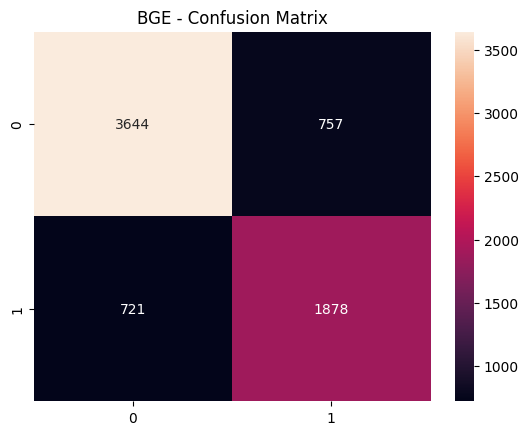

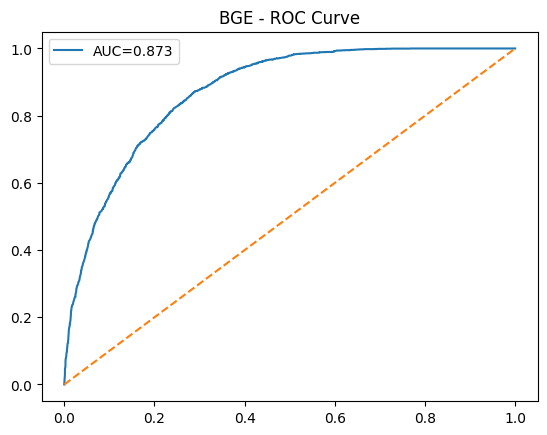

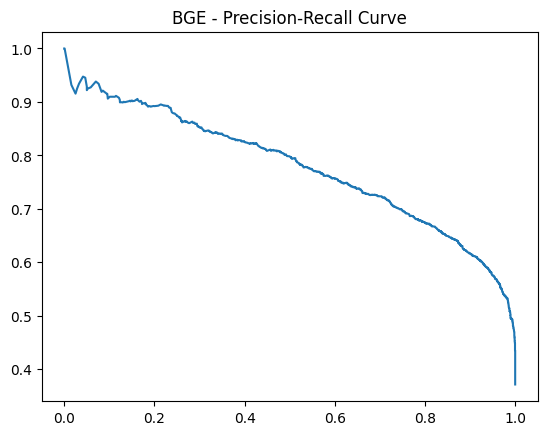

BGE Log Loss: 0.422011
BGE F1 Score: 0.717616

Running E5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The accurcy is:  0.751


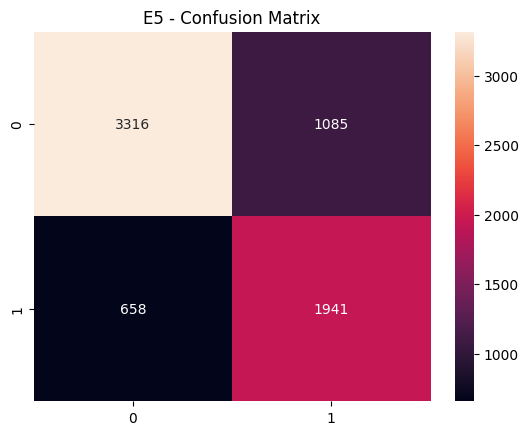

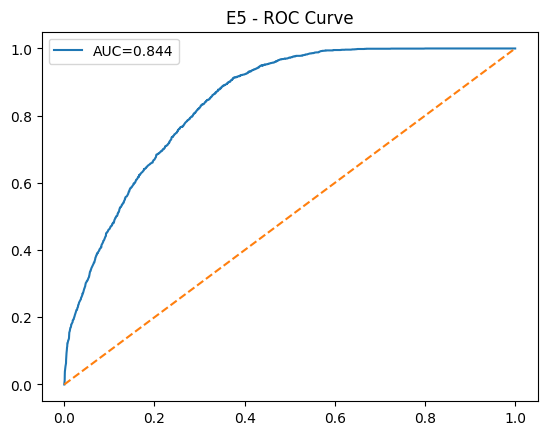

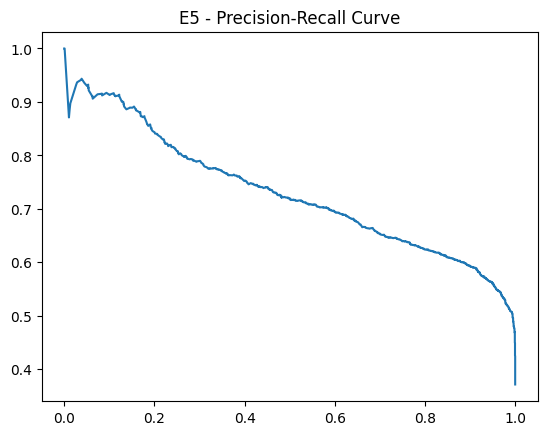

E5 Log Loss: 0.451331
E5 F1 Score: 0.690133

Running GTE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The accurcy is:  0.7628571428571429


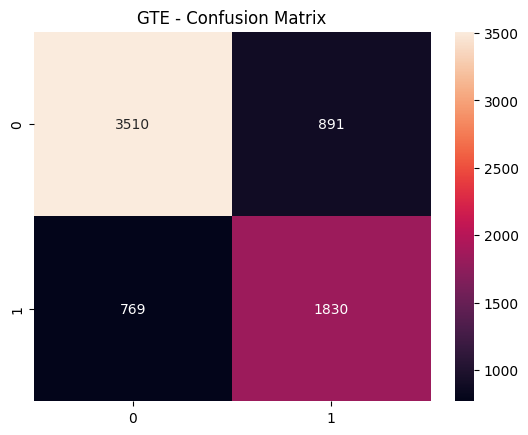

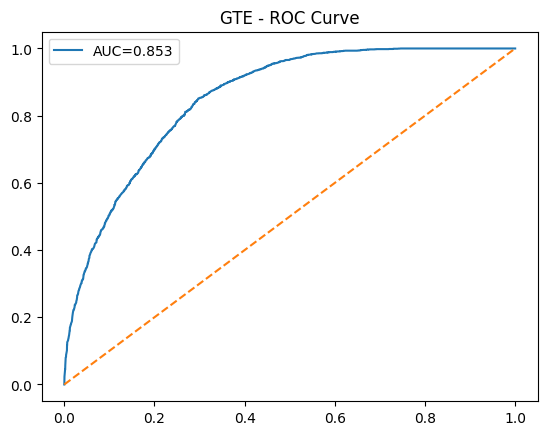

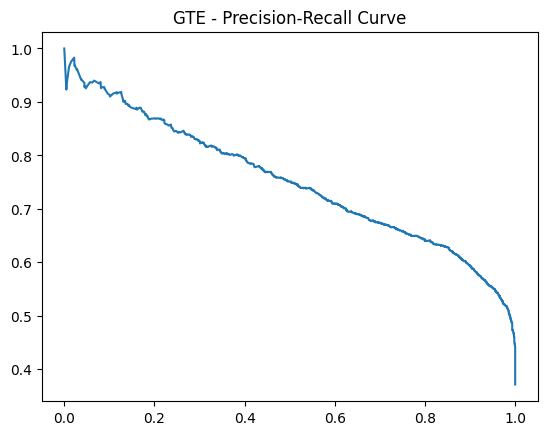

GTE Log Loss: 0.445978
GTE F1 Score: 0.687970

Running SBERT


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The accurcy is:  0.7854285714285715


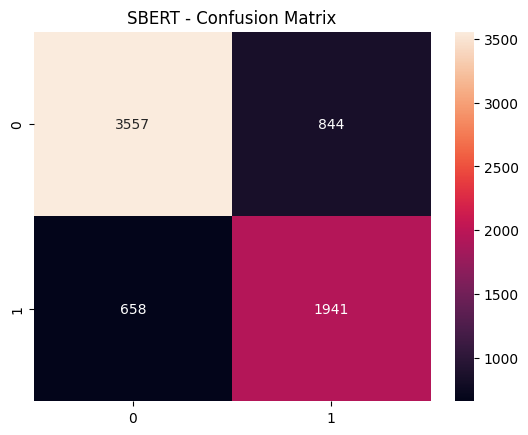

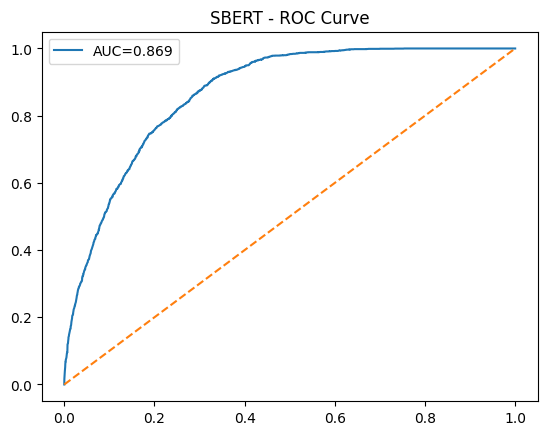

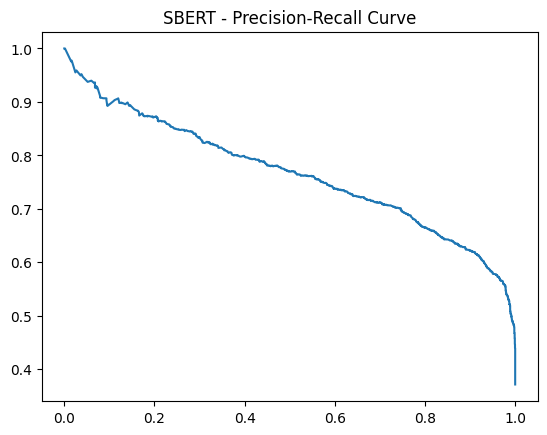

SBERT Log Loss: 0.423947
SBERT F1 Score: 0.721025


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=None,
               num_parallel_tree=None, ...),
 SentenceTransformer(
   (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
   (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_

In [ ]:
# BGE
run_embedding_model_updated("BAAI/bge-small-en-v1.5", "BGE")

# E5
run_embedding_model_updated("intfloat/e5-base-v2", "E5")

# GTE
run_embedding_model_updated("thenlper/gte-base", "GTE")

# SBERT
run_embedding_model_updated("sentence-transformers/all-MiniLM-L6-v2", "SBERT")